# **1. Perkenalan Dataset**


**Sumber Dataset**:  
Kaggle  https://www.kaggle.com/datasets/mrsimple07/laptoppriceprediction


In [1]:
import kaggle
# Download dataset dari Kaggle https://www.kaggle.com/datasets/mrsimple07/laptoppriceprediction
kaggle.api.authenticate()
kaggle.api.dataset_download_files(
    'mrsimple07/laptoppriceprediction',
    path='../laptop_price_raw',
    unzip=True
)

print('File berhasil didownload!')

Dataset URL: https://www.kaggle.com/datasets/mrsimple07/laptoppriceprediction
File berhasil didownload!


# **2. Import Library**

In [2]:
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

# **3. Memuat Dataset**

In [3]:
df = pd.read_csv('../laptop_price_raw/Laptop_price.csv')

print('Ukuran dataset :', df.shape)
df.head()

Ukuran dataset : (1000, 7)


,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


# **4. Exploratory Data Analysis (EDA)**

In [4]:
# Informasi umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB


In [5]:
# Statistik deskriptif
df.describe()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037


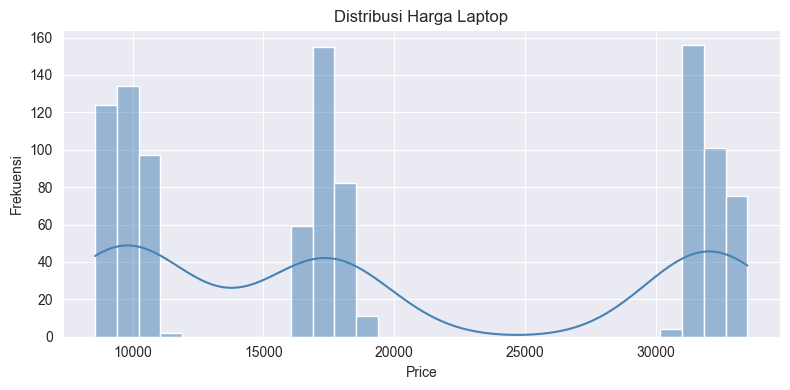

In [6]:
# Distribusi kolom target (Price)
plt.figure(figsize=(8, 4))
sns.set_style('darkgrid')
sns.histplot(df['Price'], bins=30, kde=True, color='steelblue')
plt.title('Distribusi Harga Laptop')
plt.xlabel('Price')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

In [7]:
# Melihat adanya perbedaan harga yang drastis serta membentuk kelompok
# dilakukan binning pada kolom "Price" dan diganti menjadi "Price_Category"
# setelah itu akan dilakukan EDA lebih lanjut dari binning ini
df['Price_Category'] = pd.qcut(df['Price'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

# Tampilkan rentang harga tiap kategori # Currency = Russian Ruble
bins = pd.qcut(df['Price'], q=4, retbins=True)[1]
labels = ['Low', 'Medium', 'High', 'Very High']
print('Rentang harga tiap kategori:')
for i, label in enumerate(labels):
    print(f'  {label:<10} : {bins[i]:>8.2f}  -  {bins[i+1]:>8.2f}')

Rentang harga tiap kategori:
  Low        :  8570.01  -  10114.01
  Medium     : 10114.01  -  17287.24
  High       : 17287.24  -  31566.21
  Very High  : 31566.21  -  33503.94


In [8]:
# Cek distribusi setiap kategori "Price_Category"
print('Distribusi Price_Category:')
print(df['Price_Category'].value_counts().sort_index())

Distribusi Price_Category:
Price_Category
Low          250
Medium       250
High         250
Very High    250
Name: count, dtype: int64


In [9]:
# Hapus kolom "Price" (sudah diganti "Price_Category")
df = df.drop(columns=['Price'])
df.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price_Category
0,Asus,3.830296,16,512,11.185147,2.641094,High
1,Acer,2.912833,4,1000,11.311372,3.260012,Very High
2,Lenovo,3.241627,4,256,11.853023,2.029061,Low
3,Acer,3.806248,16,512,12.280360,4.573865,High
4,Acer,3.268097,32,1000,14.990877,4.193472,Very High


Kolom kategorikal: ['Brand']


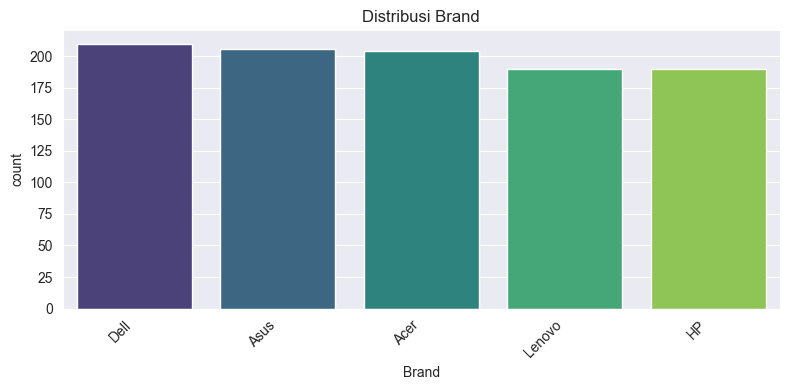

In [10]:
# Distribusi fitur kategorikal
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Kolom kategorikal:', cat_cols)

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, palette='viridis')
    plt.title(f'Distribusi {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

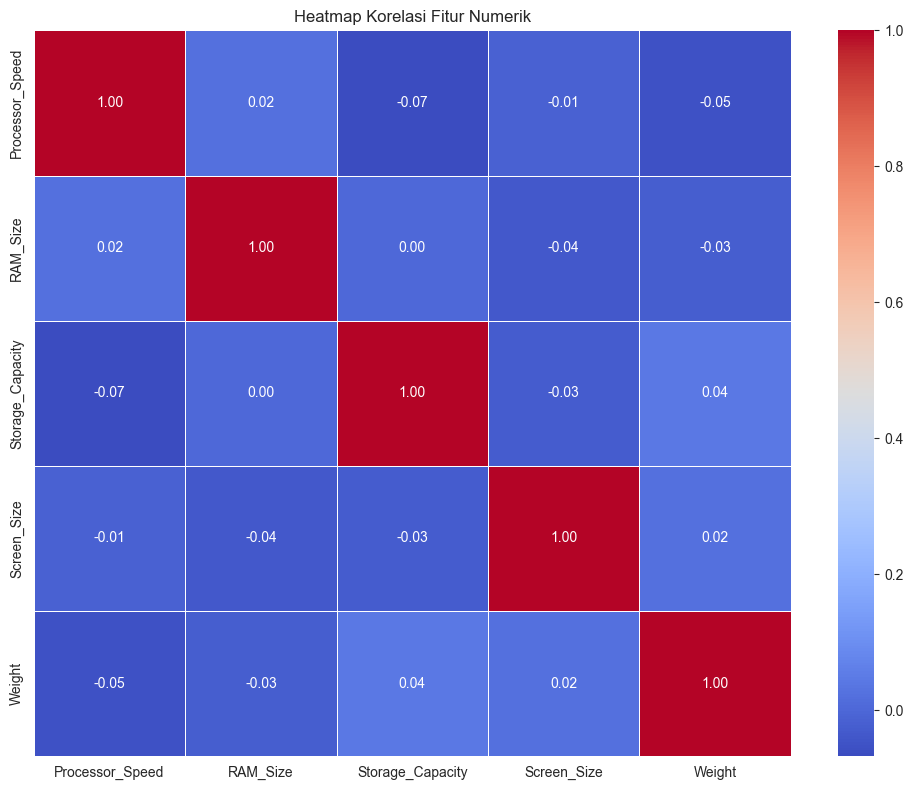

In [11]:
# Heatmap korelasi fitur numerik
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

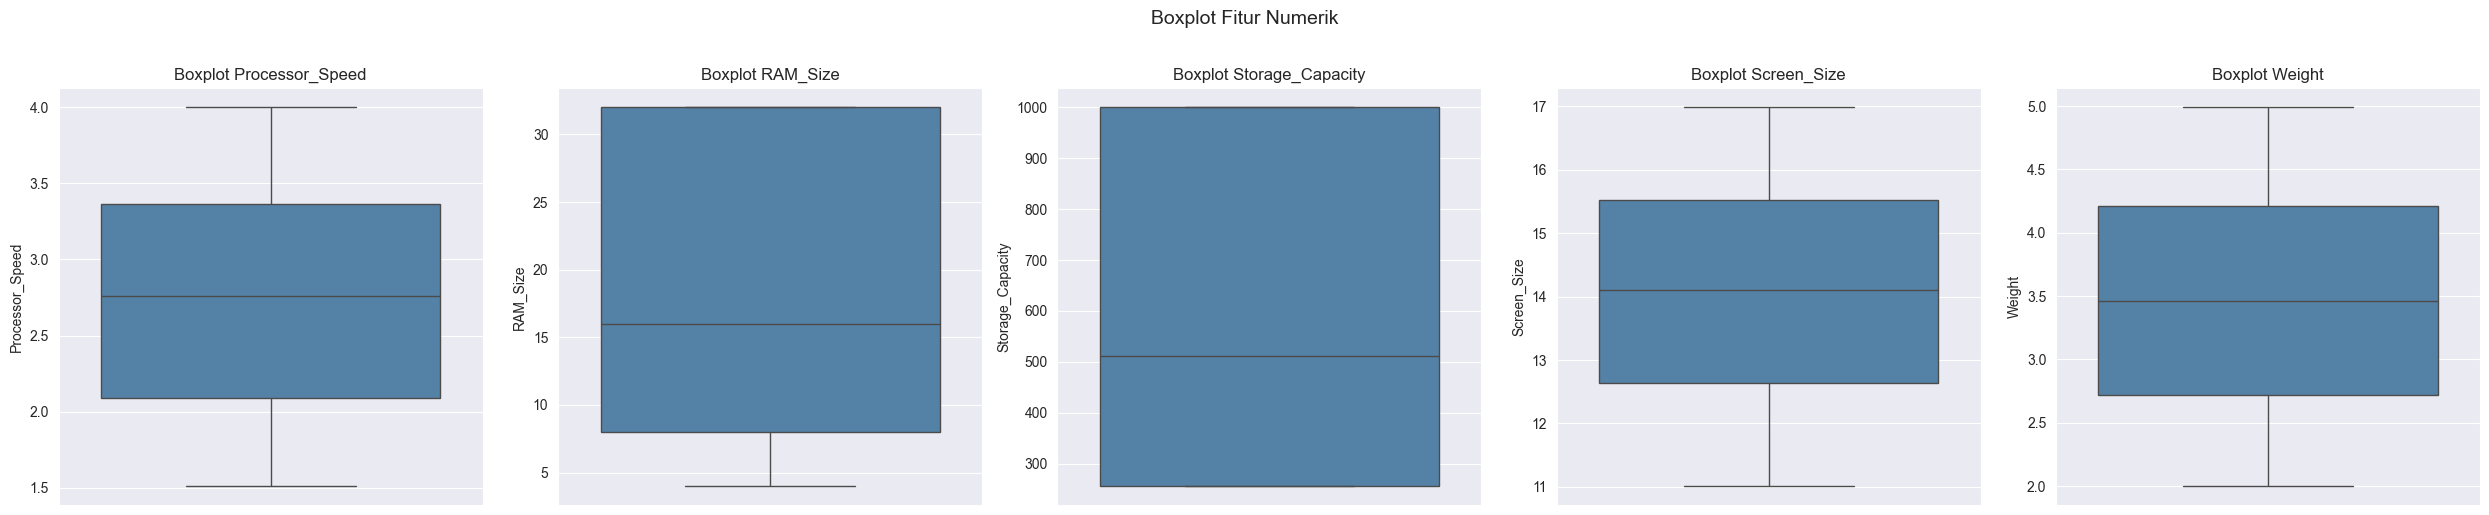

In [12]:
# Boxplot fitur numerik untuk deteksi visual outlier
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'Price']

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(f'Boxplot {col}')
plt.suptitle('Boxplot Fitur Numerik', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

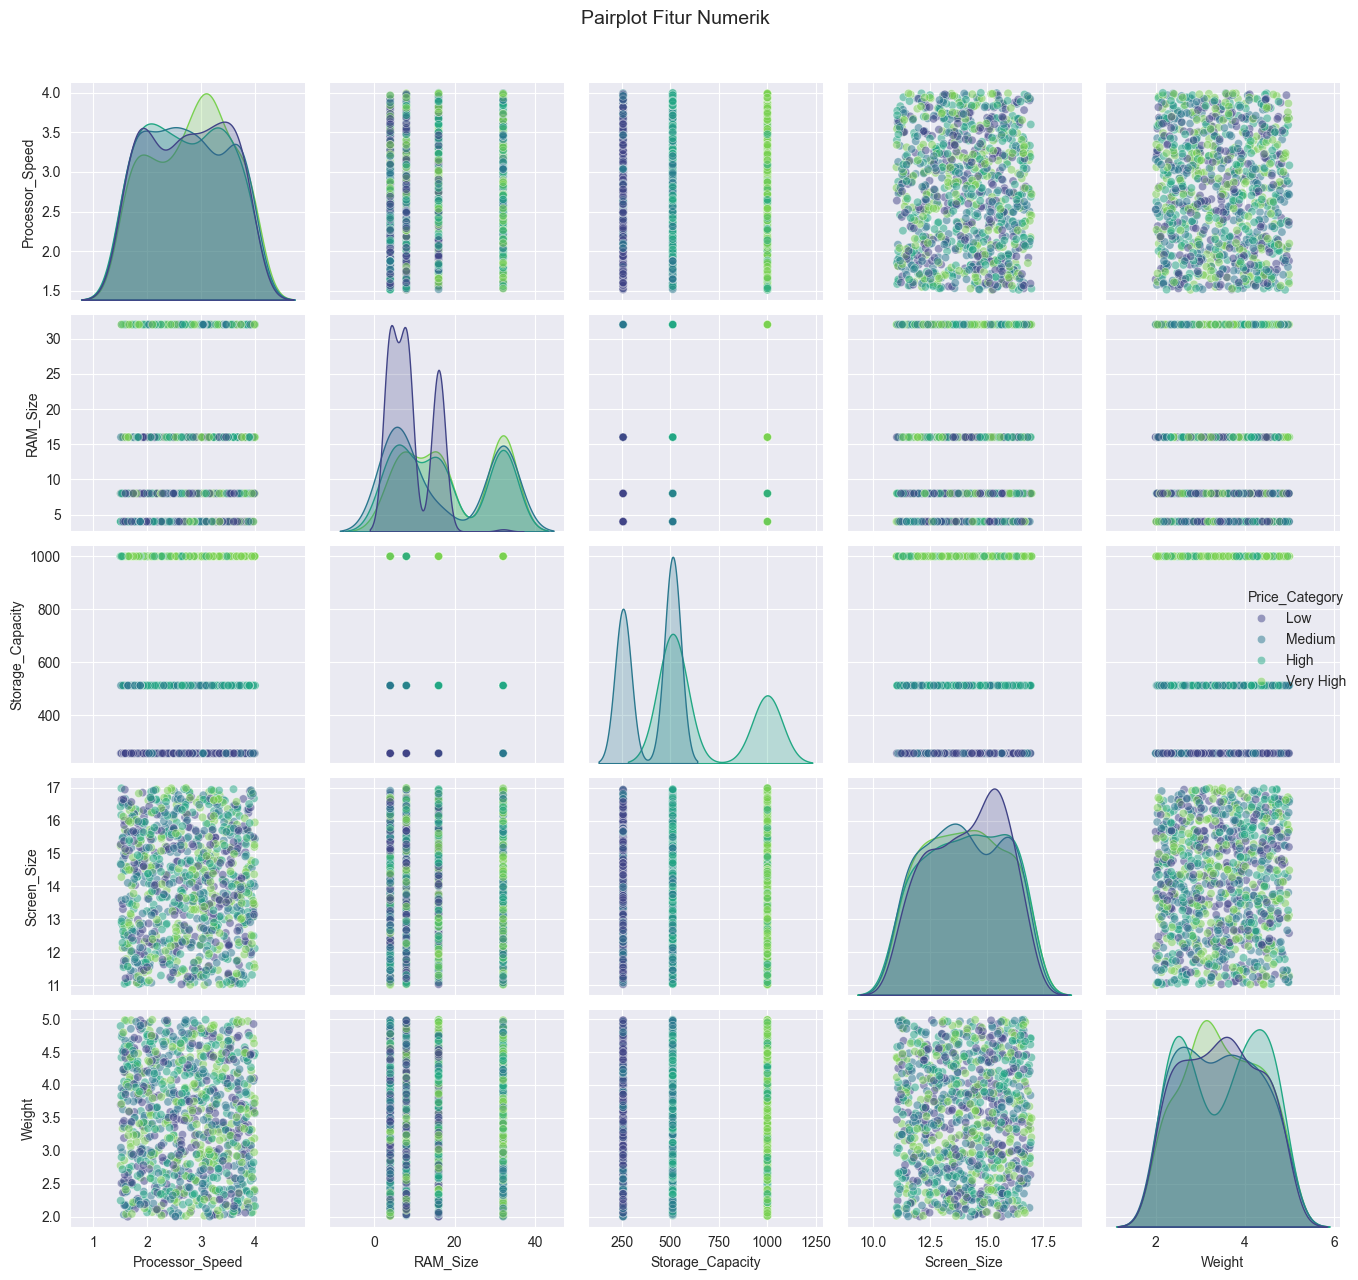

In [13]:
# Pairplot fitur numerik vs Price_Category
pairplot_cols = df.select_dtypes(include='number').columns.tolist() + ['Price_Category']
sns.pairplot(df[pairplot_cols], hue='Price_Category',
             palette='viridis', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot Fitur Numerik', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

<Figure size 900x400 with 0 Axes>

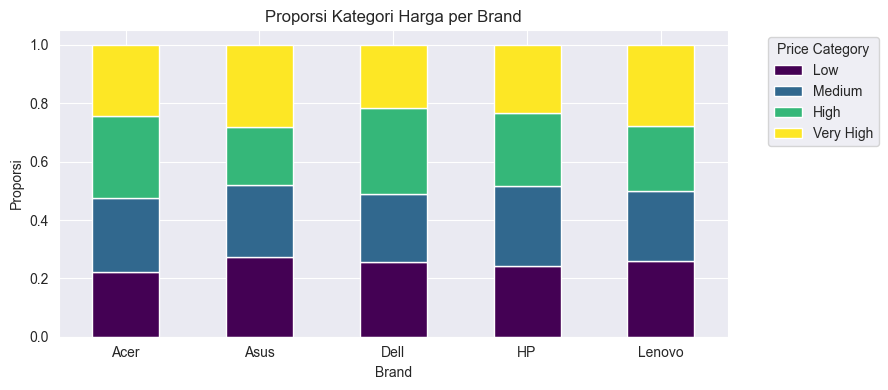

In [14]:
# Rata-rata harga per Brand
plt.figure(figsize=(9, 4))
brand_price = df.groupby('Brand')['Price_Category'].value_counts(normalize=True).unstack()
brand_price.plot(kind='bar', stacked=True, colormap='viridis', figsize=(9, 4))
plt.title('Proporsi Kategori Harga per Brand')
plt.ylabel('Proporsi')
plt.xlabel('Brand')
plt.xticks(rotation=0)
plt.legend(title='Price Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

In [15]:
# Cek missing values
df.isnull().sum()

# Tidak perlu penanganan karena tidak ada missing values
# # Hapus missing values
# df = df.dropna()
# df.isnull().sum()

Brand               0
Processor_Speed     0
RAM_Size            0
Storage_Capacity    0
Screen_Size         0
Weight              0
Price_Category      0
dtype: int64

In [16]:
# Cek data duplikat
df.duplicated().sum()

# Tidak perlu penanganan karena tidak ada data duplikat
# # Hapus duplikat
# df = df.drop_duplicates()
# df.duplicated().sum()

np.int64(0)

In [17]:
# Deteksi Outlier dengan IQR
num_features = ['Processor_Speed', 'RAM_Size', 'Storage_Capacity',
                'Screen_Size', 'Weight']

print('Jumlah outlier per fitur numerik (metode IQR):')
outlier_counts = {}
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_counts[col] = n_out
    print(f'  {col:<20} : {n_out} outlier  '
          f'(batas bawah={lower:.2f}, batas atas={upper:.2f})')

print(f'\nTotal baris sebelum penghapusan: {len(df)}')

# Tidak perlu penanganan karena tidak ada data duplikat

# # Hapus baris yang mengandung outlier pada fitur numerik
# mask_clean = pd.Series([True] * len(df), index=df.index)

# for col in num_features:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR
#     mask_clean &= (df[col] >= lower) & (df[col] <= upper)

# df = df[mask_clean].reset_index(drop=True)
# print(f'Total baris setelah penghapusan outlier: {len(df)}')

# # Visualisasi distribusi fitur numerik setelah penghapusan outlier
# fig, axes = plt.subplots(1, len(num_features), figsize=(5 * len(num_features), 4))
# for ax, col in zip(axes, num_features):
#     sns.boxplot(y=df[col], ax=ax, color='mediumseagreen')
#     ax.set_title(f'{col}\n(setelah)')
# plt.suptitle('Boxplot Setelah Penghapusan Outlier', fontsize=13, y=1.02)
# plt.tight_layout()
# plt.show()

Jumlah outlier per fitur numerik (metode IQR):
  Processor_Speed      : 0 outlier  (batas bawah=0.18, batas atas=5.27)
  RAM_Size             : 0 outlier  (batas bawah=-28.00, batas atas=68.00)
  Storage_Capacity     : 0 outlier  (batas bawah=-860.00, batas atas=2116.00)
  Screen_Size          : 0 outlier  (batas bawah=8.30, batas atas=19.87)
  Weight               : 0 outlier  (batas bawah=0.47, batas atas=6.46)

Total baris sebelum penghapusan: 1000


In [18]:
# Encode fitur kategorikal
df_encoded = df.copy()
le = LabelEncoder()

# One Hot Encoding untuk kolom 'Brand'
brand_dummies = pd.get_dummies(df_encoded['Brand'], prefix='Brand')
df_encoded = df_encoded.drop(columns=['Brand'])
df_encoded = pd.concat([df_encoded, brand_dummies], axis=1)

# Label Encode kolom kategorikal lainnya (bukan Brand, bukan target)
other_cat_cols = [c for c in df_encoded.select_dtypes(include='object').columns
                  if c != 'Price_Category']
for col in other_cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Encode target: Price_Category → integer (urutan Low=0 ... Very High=3)
cat_order = ['Low', 'Medium', 'High', 'Very High']
df_encoded['price_category'] = df_encoded['Price_Category'].map(
    {label: i for i, label in enumerate(cat_order)}
)
df_encoded = df_encoded.drop(columns=['Price_Category'])

print('Distribusi price_category:')
print(df_encoded['price_category'].value_counts().sort_index())

Distribusi price_category:
price_category
0    250
1    250
2    250
3    250
Name: count, dtype: int64


In [19]:
df_encoded.head()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Brand_Acer,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,price_category
0,3.830296,16,512,11.185147,2.641094,False,True,False,False,False,2
1,2.912833,4,1000,11.311372,3.260012,True,False,False,False,False,3
2,3.241627,4,256,11.853023,2.029061,False,False,False,False,True,0
3,3.806248,16,512,12.280360,4.573865,True,False,False,False,False,2
4,3.268097,32,1000,14.990877,4.193472,True,False,False,False,False,3


In [20]:
# Data Splitting
X = df_encoded.drop(columns=['price_category'])
y = df_encoded['price_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Jumlah data total :', len(X))
print('Jumlah data latih :', len(X_train))
print('Jumlah data test  :', len(X_test))

Jumlah data total : 1000
Jumlah data latih : 800
Jumlah data test  : 200


In [21]:
# Standarisasi fitur numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [22]:
X_train

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Brand_Acer,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo
793,3.293994,16,512,12.770434,4.059542,False,False,False,True,False
922,3.959197,16,256,16.812048,2.579480,True,False,False,False,False
447,3.611958,16,512,15.045553,4.186359,False,False,True,False,False
195,3.236741,4,256,13.996591,3.663070,False,False,False,False,True
728,2.714679,4,512,16.564131,4.986422,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
212,2.124170,8,1000,13.452664,4.489169,False,False,False,False,True
511,3.504320,8,256,11.363629,3.302157,False,True,False,False,False
687,1.514397,4,1000,14.691522,2.245897,False,False,True,False,False
703,3.658334,32,256,11.740405,3.431600,False,True,False,False,False


In [23]:
pd.DataFrame(X_train_scaled)

,0,1,2,3,4,5,6,7,8,9
0,0.778864,0.044776,-0.232708,-0.755713,0.687238,-0.519462,-0.527215,-0.498046,2.107647,-0.480384
1,1.710728,0.044776,-1.050011,1.612402,-1.020387,1.925067,-0.527215,-0.498046,-0.474463,-0.480384
2,1.224290,0.044776,-0.232708,0.577354,0.833553,-0.519462,-0.527215,2.007846,-0.474463,-0.480384
3,0.698659,-1.040697,-1.050011,-0.037267,0.229808,-0.519462,-0.527215,-0.498046,-0.474463,2.081666
4,-0.032683,-1.040697,-0.232708,1.467139,1.756629,-0.519462,-0.527215,-0.498046,-0.474463,2.081666
...,...,...,...,...,...,...,...,...,...,...
795,-0.859911,-0.678873,1.325276,-0.355972,1.182921,-0.519462,-0.527215,-0.498046,-0.474463,2.081666
796,1.073503,-0.678873,-1.050011,-1.580006,-0.186597,-0.519462,1.896761,-0.498046,-0.474463,-0.480384
797,-1.714125,-1.040697,1.325276,0.369916,-1.405259,-0.519462,-0.527215,2.007846,-0.474463,-0.480384
798,1.289257,1.492073,-1.050011,-1.359241,-0.037251,-0.519462,1.896761,-0.498046,-0.474463,-0.480384


In [24]:
y_train

793    2
922    1
447    2
195    0
728    1
      ..
212    2
511    0
687    2
703    1
135    3
Name: price_category, Length: 800, dtype: category
Categories (4, int64): [0 < 1 < 2 < 3]

In [29]:
# Save dataset
os.makedirs("laptop_price_preprocessing", exist_ok=True)

train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns.tolist())
train_df["Price_Category"] = y_train.values
train_df.to_csv("laptop_price_preprocessing/train.csv", index=False)
print(f"Train set saved! Shape: {train_df.shape}")

test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns.tolist())
test_df["Price_Category"] = y_test.values
test_df.to_csv("laptop_price_preprocessing/test.csv", index=False)
print(f"Test  set saved! Shape: {test_df.shape}")

Train set saved! Shape: (800, 11)
Test  set saved! Shape: (200, 11)
